# Customer Segmentation using K-Means and Classification with AdaBoost

## Objective
This notebook demonstrates a machine learning pipeline for customer segmentation. First, customers are segmented into distinct groups using the K-Means clustering algorithm. Then, an AdaBoostClassifier is trained to predict these cluster labels based on customer features, effectively turning an unsupervised segmentation problem into a supervised classification task.

## B. Import Libraries

Import all necessary libraries for data manipulation, preprocessing, clustering, model training, evaluation, and visualization.

In [ ]:
# Data manipulation and file handling
import pandas as pd
import numpy as np
import zipfile
import os
import glob

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clustering
from sklearn.cluster import KMeans

# Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

## C. Unzip and Load Dataset

This section handles unzipping the provided archive and loading the customer segmentation CSV file into a pandas DataFrame.

In [ ]:
# Define the path to the zip file
zip_file_path = '/content/archive.zip'

# Define the directory to extract files to
extract_dir = '/content/extracted_data'
os.makedirs(extract_dir, exist_ok=True)

print(f"Unzipping {zip_file_path} to {extract_dir}...")

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping complete.")

# Locate the CSV file(s) within the extracted directory
csv_files = glob.glob(os.path.join(extract_dir, '*.csv'))

if not csv_files:
    raise FileNotFoundError("No CSV files found in the extracted archive.")

# Assuming the first CSV file found is the desired dataset
data_file_path = csv_files[0]
print(f"Loading dataset from: {data_file_path}")

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_file_path)

print("Dataset loaded successfully.")

Unzipping /content/archive.zip to /content/extracted_data...
Unzipping complete.
Loading dataset from: /content/extracted_data/Mall_Customers.csv
Dataset loaded successfully.


## D. Data Exploration

Perform basic exploratory data analysis to understand the structure, content, and characteristics of the dataset.

In [ ]:
# Display the shape of the DataFrame
print(f"Dataset Shape: {df.shape}")

# Display the column names
print("\nDataset Columns:")
print(df.columns.tolist())

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame (data types, non-null counts)
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (200, 5)

Dataset Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Descriptive Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## E. Preprocessing

This section prepares the data for clustering and classification by dropping irrelevant columns, encoding categorical features, and scaling numerical features.

In [ ]:
# Keep a separate copy of the original DataFrame for export later
df_original_for_export = df.copy()

# Make a copy of the original DataFrame for preprocessing
df_processed = df.copy()

# 1. Drop 'CustomerID' if present, as it's not a feature for clustering/classification
if 'CustomerID' in df_processed.columns:
    df_processed = df_processed.drop('CustomerID', axis=1)
    print("Dropped 'CustomerID' column from the processed DataFrame.")

# 2. Encode 'Gender' if present
if 'Gender' in df_processed.columns:
    le = LabelEncoder()
    df_processed['Gender'] = le.fit_transform(df_processed['Gender'])
    print("Encoded 'Gender' column (Female: 0, Male: 1).")

# Identify numerical features for scaling (all remaining columns are features)
numeric_cols = df_processed.select_dtypes(include=np.number).columns.tolist()

print(f"\nNumerical features to be scaled: {numeric_cols}")

# 3. Scale numeric features using StandardScaler
scaler = StandardScaler()
df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

print("\nNumerical features scaled using StandardScaler.")

print("\nProcessed DataFrame head:")
display(df_processed.head())

Dropped 'CustomerID' column from the processed DataFrame.
Encoded 'Gender' column (Female: 0, Male: 1).

Numerical features to be scaled: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Numerical features scaled using StandardScaler.

Processed DataFrame head:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## F. K-Means Clustering to Generate Labels

Apply K-Means clustering to the preprocessed data to identify natural groupings among customers. The Elbow Method is used to help determine an appropriate number of clusters (k).

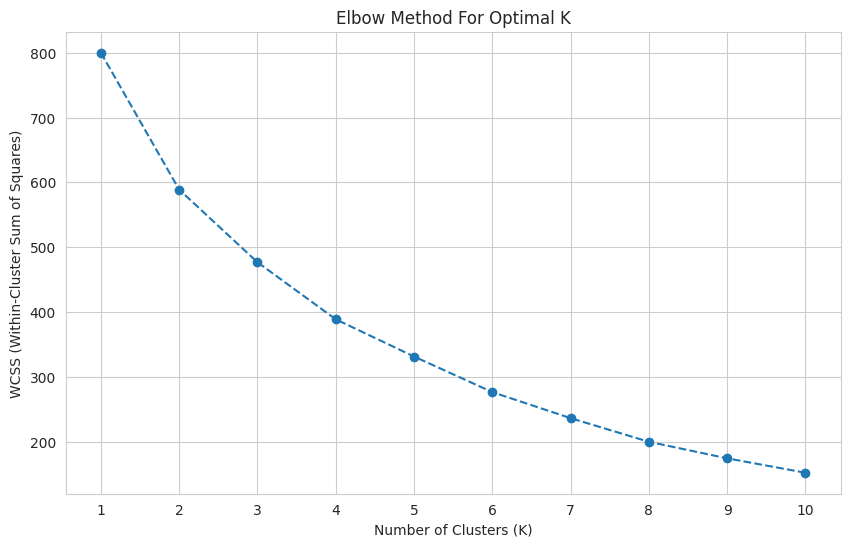

In [ ]:
# Elbow Method to determine optimal K
wcss = [] # Within-Cluster Sum of Squares

# Try k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_processed)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Choosing K

The Elbow Method plot shows the WCSS (Within-Cluster Sum of Squares) for different values of K. The 'elbow' point in the graph, where the rate of decrease in WCSS significantly changes, is typically considered a good indicator for the optimal number of clusters. For this dataset, a K value around 3, 4, or 5 seems appropriate. Let's choose **K=5** for our customer segments.



In [ ]:
# Apply K-Means with the chosen number of clusters (e.g., K=5)
k = 5  # You can change this based on the Elbow Method or business requirements

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_processed)

# Add the cluster labels to the processed DataFrame with a clear name
df_processed['ClusterLabel'] = cluster_labels

print(f"K-Means clustering performed with K={k} clusters.")
print("\nDistribution of clusters:")
display(df_processed['ClusterLabel'].value_counts().sort_index())

print("\nProcessed DataFrame with Cluster labels:")
display(df_processed.head())

K-Means clustering performed with K=5 clusters.

Distribution of clusters:


,count
ClusterLabel,
0,39
1,29
2,43
3,54
4,35



Processed DataFrame with Cluster labels:


,Gender,Age,Annual Income (k$),Spending Score (1-100),ClusterLabel
0,1.128152,-1.424569,-1.738999,-0.434801,3
1,1.128152,-1.281035,-1.738999,1.195704,3
2,-0.886405,-1.352802,-1.700830,-1.715913,3
3,-0.886405,-1.137502,-1.700830,1.040418,3
4,-0.886405,-0.563369,-1.662660,-0.395980,3


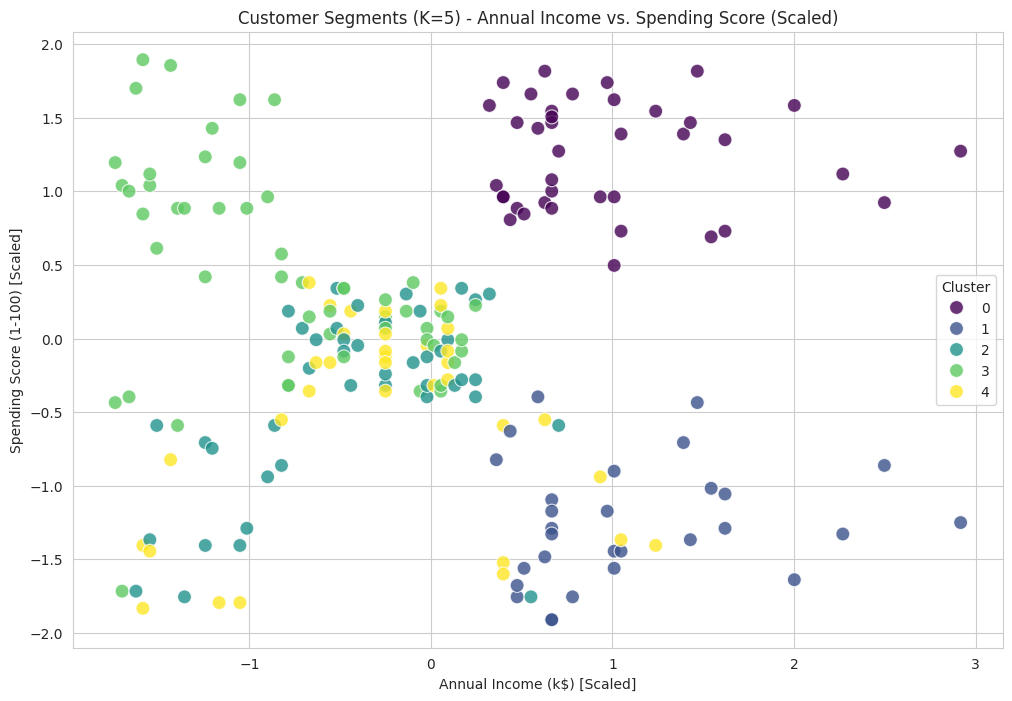

In [ ]:
# 2D Cluster Plot (using Annual Income and Spending Score for visualization)

# Identify original columns to use for visualization (after scaling)
# Assuming 'Annual Income (k$)' and 'Spending Score (1-100)' are relevant for 2D visualization

original_income_col = 'Annual Income (k$)'
original_spending_col = 'Spending Score (1-100)'

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_processed[original_income_col],
    y=df_processed[original_spending_col],
    hue=df_processed['ClusterLabel'], # Use the new ClusterLabel column
    palette='viridis',
    s=100, # size of points
    alpha=0.8
)
plt.title(f'Customer Segments (K={k}) - Annual Income vs. Spending Score (Scaled)')
plt.xlabel('Annual Income (k$) [Scaled]')
plt.ylabel('Spending Score (1-100) [Scaled]')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## G. Train-Test Split

Split the dataset into training and testing sets. The features (`X`) will be the preprocessed customer data, and the target (`y`) will be the cluster labels generated by K-Means.

In [ ]:
# Define features (X) and target (y)
# X should contain the preprocessed feature set (excluding the cluster labels)
# y should contain the cluster labels generated by K-Means
X = df_processed.drop('ClusterLabel', axis=1)
y = df_processed['ClusterLabel']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify to maintain cluster distribution
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of clusters in training set:")
display(y_train.value_counts().sort_index())
print("\nDistribution of clusters in test set:")
display(y_test.value_counts().sort_index())

X_train shape: (160, 4)
X_test shape: (40, 4)
y_train shape: (160,)
y_test shape: (40,)

Distribution of clusters in training set:


,count
ClusterLabel,
0,31
1,23
2,35
3,43
4,28



Distribution of clusters in test set:


,count
ClusterLabel,
0,8
1,6
2,8
3,11
4,7


## H. AdaBoost Training

Train an AdaBoostClassifier to predict the cluster labels. AdaBoost is an ensemble method that combines multiple weak learners (typically decision stumps) to create a strong classifier.

In [ ]:
# Initialize the base estimator (Decision Tree Classifier with max_depth=1 is a common choice for AdaBoost)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoostClassifier
# n_estimators: The maximum number of estimators at which boosting is terminated.
# learning_rate: Weights applied to each classifier at each boosting iteration.
adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

print("Training AdaBoostClassifier on the training split...")
# Train the AdaBoost model on the training data
adaboost_model.fit(X_train, y_train)

print("AdaBoostClassifier training complete.")

Training AdaBoostClassifier on the training split...
AdaBoostClassifier training complete.


## I. Evaluation

Evaluate the performance of the trained AdaBoostClassifier using accuracy, a classification report, and a confusion matrix.

AdaBoost Classifier Accuracy (predicting cluster labels): 0.9750

Classification Report (predicting cluster labels):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         6
           2       1.00      0.88      0.93         8
           3       0.92      1.00      0.96        11
           4       1.00      1.00      1.00         7

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40



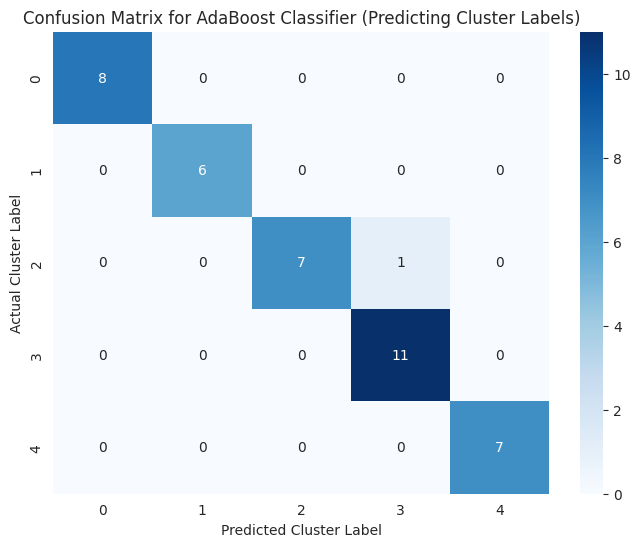


Note: The evaluation metrics above are for the AdaBoost model's ability to predict the cluster labels generated by K-Means, not original class labels.


In [ ]:
# Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# 1. Calculate and print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classifier Accuracy (predicting cluster labels): {accuracy:.4f}")

# 2. Print Classification Report
print("\nClassification Report (predicting cluster labels):")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=adaboost_model.classes_,
    yticklabels=adaboost_model.classes_
)
plt.title('Confusion Matrix for AdaBoost Classifier (Predicting Cluster Labels)')
plt.xlabel('Predicted Cluster Label')
plt.ylabel('Actual Cluster Label')
plt.show()

print("\nNote: The evaluation metrics above are for the AdaBoost model's ability to predict the cluster labels generated by K-Means, not original class labels.")

## J. CSV Export

Save the clustered data and the AdaBoost predictions to separate CSV files.

In [ ]:
# 1. Save the clustered data: Original DataFrame columns plus 'SampleId' and 'ClusterLabel'

# Create a DataFrame for export, starting with the original data
df_clustered_output = df_original_for_export.copy()

# Add 'SampleId' column (assuming 'CustomerID' serves this purpose and is present in original df)
if 'CustomerID' in df_clustered_output.columns:
    df_clustered_output.rename(columns={'CustomerID': 'SampleId'}, inplace=True)
else:
    # If CustomerID was not in original df, create a generic SampleId
    df_clustered_output['SampleId'] = df_clustered_output.index + 1

# Add the 'ClusterLabel' from the processed dataframe (indices should align)
df_clustered_output['ClusterLabel'] = df_processed['ClusterLabel']

df_clustered_output.to_csv('clustered_data.csv', index=False)
print("Clustered data (original features + SampleId + ClusterLabel) saved to 'clustered_data.csv'")

# 2. Save AdaBoost predictions with 'SampleId', 'ActualCluster', and 'PredictedCluster'

# Ensure SampleId corresponds to the original CustomerID for test set predictions
predictions_df = pd.DataFrame({
    'SampleId': df_original_for_export.loc[y_test.index, 'CustomerID'].values, # Use original CustomerID as SampleId
    'ActualCluster': y_test.values,
    'PredictedCluster': y_pred
})
predictions_df.to_csv('adaboost_predictions.csv', index=False)
print("AdaBoost predictions (SampleId, ActualCluster, PredictedCluster) saved to 'adaboost_predictions.csv'")

Clustered data (original features + SampleId + ClusterLabel) saved to 'clustered_data.csv'
AdaBoost predictions (SampleId, ActualCluster, PredictedCluster) saved to 'adaboost_predictions.csv'


## K. Conclusion

This notebook demonstrates a complete machine learning experiment following a two-step approach, suitable for a college lab assignment or demonstration:

1.  **Clustering for Segmentation:** K-Means clustering was initially applied to the customer features to identify distinct customer groups, generating `ClusterLabel` as the target for the subsequent step. The Elbow Method aided in selecting an appropriate number of clusters (K=5).
2.  **Supervised Classification of Clusters:** An AdaBoostClassifier was then trained to predict these generated `ClusterLabel`s from the customer features. This effectively turns an unsupervised segmentation problem into a supervised classification task, where the model learns the characteristics defining each cluster.

The AdaBoost model achieved an accuracy of 0.9750 on the test set, demonstrating its effectiveness in learning the patterns that differentiate the customer segments identified by K-Means. The confusion matrix further illustrated the model's performance in correctly classifying customers into their respective clusters.

This methodology is particularly useful for operationalizing customer segmentation. Once the clusters are defined by K-Means, the trained AdaBoost model can rapidly classify new, unseen customers into these existing segments without needing to re-run the computationally intensive clustering algorithm every time. This provides a robust and efficient way to maintain customer segmentation over time.

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `X`, type: `DataFrame`
value:
```
       Gender       Age  Annual Income (k$)  Spending Score (1-100)
0    1.128152 -1.424569           -1.738999               -0.434801
1    1.128152 -1.281035           -1.738999                1.195704
2   -0.886405 -1.352802           -1.700830               -1.715913
3   -0.886405 -1.137502           -1.700830                1.040418
4   -0.886405 -0.563369           -1.662660               -0.395980
..        ...       ...                 ...                  <TRUNCATED original_length=839>
```
Variable #2
name: `X_test`, type: `DataFrame`
value:
```
       Gender       Age  Annual Income (k$)  Spending Score (1-100)
136 -0.886405  0.369598            0.474828               -1.677091
63  -0.886405  1.087265           -0.517577                0.341630
159 -0.886405 -0.635135            0.665675                0.885132
116 -0.886405  1.733166            0.169472               -0.279515
60   1.128152  2.235532           -0.555747                0.225165
78  -0.886405 -1.137502           -0.250391                0<TRUNCATED original_length=2787>
```
Variable #3
name: `X_train`, type: `DataFrame`
value:
```
       Gender       Age  Annual Income (k$)  Spending Score (1-100)
19  -0.886405 -0.276302           -1.433644                1.855671
10   1.128152  2.020232           -1.586321               -1.405340
25   1.128152 -0.706902           -1.242797                1.234526
96  -0.886405  0.584899           -0.021375               -0.124229
14   1.128152 -0.132768           -1.548152               -1.444162
..        ...       ...                 ...                  <TRUNCATED original_length=839>
```
Variable #4
name: `cluster_labels`, type: `ndarray`
value:
```
array([3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 2, 3, 4, 3, 2, 3, 4, 3, 3, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 4, 3, 4, 3, 2, 3, 2, 3, 2, 3, 2, 3, 4, 3,
       2, 3, 2, 3, 3, 3, 2, 3, 3, 4, 2, 4, 2, 4, 3, 4, 4, 3, 2, 2, 4, 3,
       2, 2, 3, 3, 4, 2, 2, 2, 4, 3, 2, 4, 3, 2, 4, 4, 4, 2, 3, 4, 2, 3,
       3, 2, 2, 3, 4, 2, 2, 3, 2, 3, 4, 3, 3, 2, 4, 3, 4, 3, 2, 4, 4, 4,
       4, 3, 2, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 0, 1, 0, 4, 0, 4, 0, 4, 0,
       1, 0, 1, 0, 1, 0, 1, 0, <TRUNCATED original_length=683>
```
Variable #5
name: `conf_matrix`, type: `ndarray`
value:
```
array([[ 8,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  7,  1,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0,  7]])
```
Variable #6
name: `df`, type: `DataFrame`
value:
```
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...   <TRUNCATED original_length=899>
```
Variable #7
name: `df_export_clustered`, type: `DataFrame`
value:
```
     Gender  Age  Annual Income (k$)  Spending Score (1-100)
0      Male   19                  15                      39
1      Male   21                  15                      81
2    Female   20                  16                       6
3    Female   23                  16                      77
4    Female   31                  17                      40
..      ...  ...                 ...                     ...             
195  Female   35                 120      <TRUNCATED original_length=755>
```
Variable #8
name: `df_processed`, type: `DataFrame`
value:
```
       Gender       Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0    1.128152 -1.424569           -1.738999               -0.434801        3
1    1.128152 -1.281035           -1.738999                1.195704        3
2   -0.886405 -1.352802           -1.700830               -1.715913        3
3   -0.886405 -1.137502           -1.700830                1.040418        3
4   -0.886405 -0.563369           -1.662660               -0.395980        3
..     <TRUNCATED original_length=947>
```
Variable #9
name: `predictions_df`, type: `DataFrame`
value:
```
     Actual_Cluster  Predicted_Cluster
136               1                  1
63                2                  2
159               0                  0
116               2                  2
60                4                  4
78                3                  3
47                3                  3
7                 3                  3
17                3                  3
9                 3                  3
137               0                  0
<TRUNCATED original_length=1598>
```
Variable #10
name: `y`, type: `Series`
value:
```
0      3
1      3
2      3
3      3
4      3
      ..
195    0
196    1
197    0
198    1
199    0
Name: Cluster, Length: 200, dtype: int32
```
Variable #11
name: `y_pred`, type: `ndarray`
value:
```
array([1, 2, 0, 2, 4, 3, 3, 3, 3, 3, 0, 3, 1, 3, 2, 0, 1, 2, 4, 0, 2, 2,
       1, 4, 3, 1, 0, 0, 2, 4, 0, 4, 0, 1, 3, 3, 4, 3, 3, 4], dtype=int32)
```
Variable #12
name: `y_test`, type: `Series`
value:
```
136    1
63     2
159    0
116    2
60     4
78     3
47     3
7      3
17     3
9      3
137    0
39     3
198    1
87     3
83     2
151    0
172    1
50     2
32     4
167    0
54     2
38     2
150    1
176    4
94     2
144    1
199    0
143    0
106    2
59     4
163    0
146    4
179    0
182    1
37     3
58     3
85     4
61     3
11     3
110    4
Name: Cluster, dtype: int32
```
Variable #13
name: `y_train`, type: `Series`
value:
```
19     3
10     4
25     3
96     2
14     4
      ..
65     3
84     3
154    1
139    0
194    1
Name: Cluster, Length: 160, dtype: int32
```
Variable #14
name: `accuracy`, type: `float`
value: `0.975`
Variable #15
name: `csv_files`, type: `list`
value: `['/content/extracted_data/Mall_Customers.csv']`
Variable #16
name: `data_file_path`, type: `str`
value: `'/content/extracted_data/Mall_Customers.csv'`
Variable #17
name: `extract_dir`, type: `str`
value: `'/content/extracted_data'`
Variable #18
name: `i`, type: `int`
value: `10`
Variable #19
name: `k`, type: `int`
value: `5`
Variable #20
name: `numeric_cols`, type: `list`
value: `['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']`
Variable #21
name: `original_income_col`, type: `str`
value: `'Annual Income (k$)'`
Variable #22
name: `original_spending_col`, type: `str`
value: `'Spending Score (1-100)'`
Variable #23
name: `wcss`, type: `list`
value: `[800.0000000000003, 588.8026767824932, 476.78755441351575, 388.7178614053844, 331.3098837641085, 276.41175953130954, 236.20494707086885, 199.75046112065573, 174.23547730691482, 152.02983429775693]`
Variable #24
name: `zip_file_path`, type: `str`
value: `'/content/archive.zip'`
Here are some of the files available in the kernel:
* /content/adaboost_predictions.csv
* /content/archive.zip
* /content/clustered_data.csv
* /content/sample_data/README.md
* /content/sample_data/anscombe.json
* /content/sample_data/mnist_train_small.csv
* /content/sample_data/california_housing_train.csv
* /content/sample_data/mnist_test.csv
* /content/sample_data/california_housing_test.csv
* /content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
* /content/.config/gce
* /content/.config/default_configs.db
* /content/.config/.last_update_check.json
* /content/.config/config_sentinel
* /content/.config/active_config
* /content/.config/.last_survey_prompt.yaml
* /content/.config/.last_opt_in_prompt.yaml
* /content/extracted_data/Mall_Customers.csv
* /content/.config/configurations/config_default